# Solução do problema local


\begin{aligned}
      &\frac{\partial}{\partial y} \left( C_{11}(y)\frac{\partial N_{11}}{\partial y} + C_{11}(y)\right) = 0, \\
      &\frac{\partial}{\partial y} \left( C_{11}(y)\frac{\partial N_{12}}{\partial y} + C_{12}(y)\right) = 0, \\
      &\langle N_{11} \rangle = \langle N_{12} \rangle = 0, \quad y \in \{y_I\} \quad (\text{Interface conditions}),\\
      &\langle N^{(1)}_{11} \rangle = \langle N^{(1)}_{12} \rangle = 0, \quad y \in [0, y_I], \\
      &\langle N^{(2)}_{11} \rangle = \langle N^{(2)}_{12} \rangle = 0, \quad y \in [y_I, y_e]. \quad (\text{Uniqueness conditions}),
\end{aligned}


# Solução do problema homogeneizado
$\newcommand{\partialderivative}[2]{\frac{\partial #1}{\partial #2}}$
\begin{aligned}
        \hat{C}_{11} \frac{\partial^2 u_r^{(0)}}{\partial r^2}
        + \hat{C}_{11} \frac{1}{r} \partialderivative{u_r^{(0)}}{r}
        - \hat{C}_{11} \frac{u_r^{(0)}}{r^2} = 0.
\end{aligned}


### Formulação fraca
\begin{aligned}
  \int_{Ω}\left(
  \hat{C}_{11} \frac{\partial^2 u_r^{(0)}}{\partial r^2}
  + \hat{C}_{11} \frac{1}{r} \partialderivative{u_r^{(0)}}{r}
  - \hat{C}_{11} \frac{u_r^{(0)}}{r^2} \right) vdr= 0,\\
    \int_{Ω}\hat{C}_{11} \frac{\partial^2 u_r^{(0)}}{\partial r^2}vdr
  + \int_{Ω}\hat{C}_{11} \frac{1}{r} \partialderivative{u_r^{(0)}}{r}vdr
  - \int_{Ω}\hat{C}_{11} \frac{u_r^{(0)}}{r^2}vdr
  = 0.
\end{aligned}


#### Aplicando a regra do produto em cada termo




\begin{aligned}
    ∫_{Ω} \frac{\partial^2 u_r^{(0)}}{\partial r^2}vdr =
    \frac{\partial u_r^{(0)}}{\partial r}v |_{\partial \Omega} - ∫_{Ω} \frac{\partial u_r^{(0)}}{\partial r} \frac{\partial v^{(0)}}{\partial r} dr,\\
    ∫_{Ω} \frac{1}{r} \partialderivative{u_r^{(0)}}{r}vdr = u_r^{(0)}\frac vr + ∫_{Ω}\frac{u_r^{(0)}}{r^2}vdr,\\
    ∫_{Ω}\frac{u_r^{(0)}}{r^2}vdr.
\end{aligned}

 #### Somando os termos
\begin{aligned}
  2∫_{Ω}\frac{u_r^{(0)}}{r^2}vdr - ∫_{Ω} \frac{\partial u_r^{(0)}}{\partial r} \frac{\partial v^{(0)}}{\partial r} dr + \frac{\partial u_r^{(0)}}{\partial r}v |_{∂Ω}  + u_r^{(0)}\frac vr|_{∂Ω} = 0.
\end{aligned}

Essa seria a forma fraca do problema homogeneizado.

#

# Solução FEniCS

In [1]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

--2026-07-30 23:01:21--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2026-07-30 23:01:22 (22.1 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/e12a85f2/releases/pybi

Digite o número de camadas: 100
Digite a fração volumétrica da camada 1 (0 a 1): 0.5
[9.01, 9.02, 9.03, 9.04, 9.049999999999999, 9.059999999999999, 9.069999999999999, 9.079999999999998, 9.089999999999998, 9.099999999999998, 9.109999999999998, 9.119999999999997, 9.129999999999997, 9.139999999999997, 9.149999999999997, 9.159999999999997, 9.169999999999996, 9.179999999999996, 9.189999999999996, 9.199999999999996, 9.209999999999996, 9.219999999999995, 9.229999999999995, 9.239999999999995, 9.249999999999995, 9.259999999999994, 9.269999999999994, 9.279999999999994, 9.289999999999994, 9.299999999999994, 9.309999999999993, 9.319999999999993, 9.329999999999993, 9.339999999999993, 9.349999999999993, 9.359999999999992, 9.369999999999992, 9.379999999999992, 9.389999999999992, 9.399999999999991, 9.409999999999991, 9.419999999999991, 9.42999999999999, 9.43999999999999, 9.44999999999999, 9.45999999999999, 9.46999999999999, 9.47999999999999, 9.48999999999999, 9.49999999999999, 9.50999999999999, 9.5199

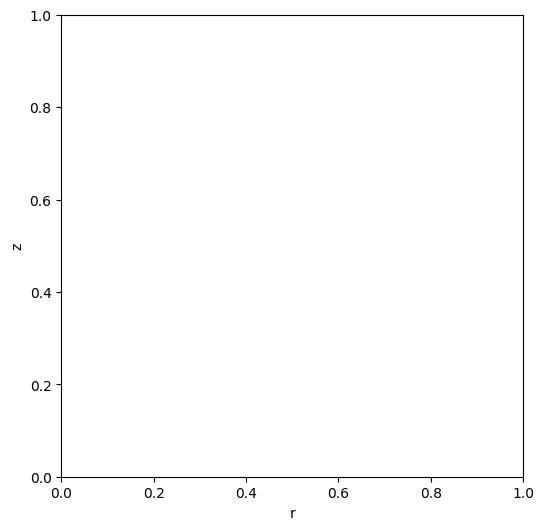

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_4f750817ecc896f3bedcb4ff8c9f3352153b1b38

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00353122 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.402853 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representatio

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_3801828c0f66b7190a7fd5819465b3d5b34b9149

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00192285 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.00978684 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representat

Resolvendo modelo MEF Heterogêneo...
Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_8f1dcac14b48abb9ef8ea37f8ebf56af78ef551f

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    2
  Coefficients:              '[f_14, f_15]'
  Unique elements:           'Vector<2 x CG1(?,?)>, DG0(?,?)'
  Unique sub elements:       'Vector<2 x CG1(?,?)>, DG0(?,?), CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 5
INFO:FFC:  quadrature_degree: 5
INFO:FFC:  
INFO:FFC:Compiler sta

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_cd40aaaf5bc0b68be1a587d7bb9a08da6d0820e7

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00146008 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.00851917 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representat

Resolvendo modelo MHA Homogeneizado...
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_fe3f8ad4d4d9412e0ee0763d4963509380b3f745

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'Vector<2 x CG1(?,?)>'
  Unique sub elements:       'Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 5
INFO:FFC:  quadrature_degree: 5
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.020412 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:----------------------------------------

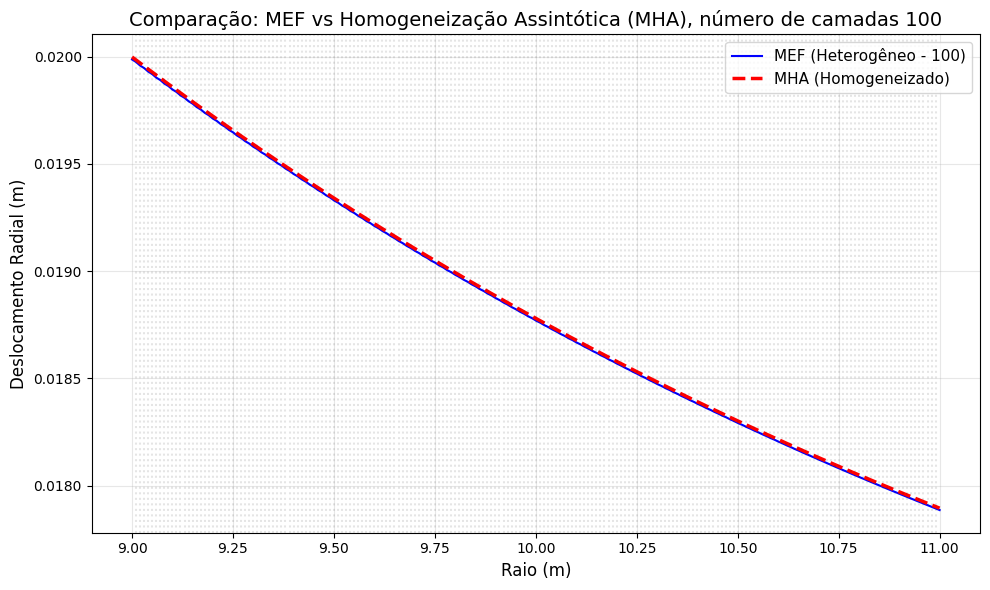

In [2]:
from dolfin import *
import numpy as np
import matplotlib.pyplot as plt

def comparar_mha_mef():
    # =======================================================
    # 1. PARÂMETROS GEOMÉTRICOS E FÍSICOS
    # =======================================================
    R_int, R_ext = 9.0, 11.0 #Raio interno e externo
    H = 2.0 # Expessura

    #Em resumo, enquanto aplicações estruturais leves podem operar próximas a 1 MPa
    #, os componentes críticos de Oil & Gas e sistemas de armazenamento de alta pressão operam tipicamente entre 10 MPa e 50 MPa

    P_int = 60e6 # Pressão interna

    # Material 1 (Ex: Aço) e Material 2 (Ex: Alumínio)
    E1, nu1 = 200e9, 0.3
    E2, nu2 = 70e9, 0.33

    # Número de camadas (Volume fraction 50/50)
    # N_camadas = input("Digite o número de camadas (ex: 40): ")
    # N_camadas = int(N_camadas)
    N_celulas = int(input("Digite o número de camadas: ")) # Número de períodos/células (Cada célula contém 1 camada de cada material)

    V1 = float(input("Digite a fração volumétrica da camada 1 (0 a 1): ")) # Fração de volume da camada 1
    V2 = 1-V1 # Fração de volume da camada 2

    espessura_celula = (R_ext - R_int) / N_celulas
    h1 = V1 * espessura_celula
    h2 = V2 * espessura_celula

    #interfaces = np.linspace(R_int, R_ext, N_camadas + 1)[1:-1] # Exclui as extremidades
    interfaces = []
    raio_atual = R_int

    for i in range(N_celulas):
        raio_atual += h1
        interfaces.append(raio_atual) # Adiciona a interface Material 1 -> Material 2
        raio_atual += h2
        if i < N_celulas - 1:
            interfaces.append(raio_atual) # Adiciona a interface Material 2 -> Material 1 da próxima célula

    print(interfaces)

    # 'interfaces' agora contém as posições exatas onde a propriedade deve mudar,
    # e a malha (mesh) tem nós milimetricamente posicionados nessas coordenadas!

    # =======================================================
    # 2. CÁLCULO DOS COEFICIENTES HOMOGENEIZADOS (MHA)
    # Baseado na Teoria de Laminação (Homogeneização Assintótica 1D)
    # =======================================================
    def get_C_matrix(E, nu):
        # Retorna C11 e C12 para material isotrópico
        C11 = E * (1 - nu) / ((1 + nu) * (1 - 2 * nu))
        C12 = E * nu / ((1 + nu) * (1 - 2 * nu))
        G = E / (2 * (1 + nu))
        return C11, C12, G

    C11_1, C12_1, G_1 = get_C_matrix(E1, nu1)
    C11_2, C12_2, G_2 = get_C_matrix(E2, nu2)


    # Por que a soluçãp diverge quando altero as frações volumétricas?
    # Possivelmente pois este código não está completamente adaptado à frações fora do 50/50

    # Coeficientes Efetivos (Média Harmônica na direção radial, Aritmética nas outras)
    C11_eff = 1.0 / (V1/C11_1 + V2/C11_2)
    C12_eff = C11_eff * (V1 * C12_1/C11_1 + V2 * C12_2/C11_2)
    C22_eff = (V1*C11_1 + V2*C11_2) - (V1*(C12_1**2)/C11_1 + V2*(C12_2**2)/C11_2) + (C12_eff**2)/C11_eff # Esse eu ainda não calculei
    G_eff = 1.0 / (V1/G_1 + V2/G_2) # Nem esse

    # =======================================================
    # 3. MALHA E FRONTEIRAS (Comum para ambos os modelos)
    # =======================================================
    # 800 elementos em R para garantir 20 elementos DENTRO de cada camada

    # Usamos um multiplicador para garantir que a proporção vire números inteiros de elementos
    resolucao_malha = 20 # Mude isso para refinar mais ou menos a malha

    # Número de elementos dentro de uma única célula para cada material
    nel_1 = int(V1 * resolucao_malha)
    nel_2 = int(V2 * resolucao_malha)
    nel_celula = nel_1 + nel_2

    # Total de elementos radiais na malha inteira
    n_elements_r = N_celulas * nel_celula
    n_elements_z = 10

    print(f'Número de elementos em r {n_elements_r}')
    print(f'Número de elementos em r {n_elements_z}')

    mesh = RectangleMesh(Point(R_int, 0.0), Point(R_ext, H), n_elements_r, n_elements_z)
    boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)
    CompiledSubDomain("near(x[0], R_int)", R_int=R_int).mark(boundaries, 1) # Parede Interna
    CompiledSubDomain("near(x[1], 0.0)").mark(boundaries, 2)                # Base
    CompiledSubDomain("near(x[1], H)", H=H).mark(boundaries, 3)             # Topo
    ds_custom = Measure("ds", domain=mesh, subdomain_data=boundaries)

    # Visualizar a malha
    # plot(mesh)

    # Mostrar eixos
    plt.figure(figsize=(10, 6))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('r')
    plt.ylabel('z')
    plt.show()

    V = VectorFunctionSpace(mesh, "CG", 1)
    u = TrialFunction(V)
    v = TestFunction(V)
    x = SpatialCoordinate(mesh)
    r = x[0]

    # Condições de Contorno (Travando Z para simular Estado Plano 1D do seu Notebook)
    bcs = [
        DirichletBC(V.sub(1), Constant(0.0), boundaries, 2), # Trava base
        DirichletBC(V.sub(1), Constant(0.0), boundaries, 3)  # Trava topo
    ]

    T = -Constant(P_int) * FacetNormal(mesh)
    L = inner(T, v) * r * ds_custom(1)

    # =======================================================
    # 4. MODELO 1: MEF HETEROGÊNEO (Múltiplas Camadas)
    # =======================================================


    class PeriodicProperty(UserExpression):
        def __init__(self, val1, val2, interfaces, **kwargs):
            super().__init__(**kwargs)
            self.val1, self.val2 = val1, val2
            self.interfaces = interfaces
        def eval(self, values, x):
            idx = 0
            for r_int in self.interfaces:
                if x[0] <= r_int: break
                idx += 1
            values[0] = self.val1 if idx % 2 == 0 else self.val2
        def value_shape(self): return ()

    E_func = PeriodicProperty(E1, E2, interfaces, degree=0)
    nu_func = PeriodicProperty(nu1, nu2, interfaces, degree=0)

    lmbda_func = (E_func * nu_func) / ((1.0 + nu_func) * (1.0 - 2.0 * nu_func))
    mu_func = E_func / (2.0 * (1.0 + nu_func))

    def eps(u):
        return sym(as_tensor([[u[0].dx(0), 0, u[0].dx(1)], [0, u[0]/r, 0], [u[1].dx(0), 0, u[1].dx(1)]]))

    def sigma_mef(u):
        return lmbda_func * tr(eps(u)) * Identity(3) + 2.0 * mu_func * eps(u)

    print("Resolvendo modelo MEF Heterogêneo...")
    a_mef = inner(sigma_mef(u), eps(v)) * r * dx # Multiplica-se a integral por r (O Jacobiano da métrica cilíndrica)
    u_mef = Function(V)
    solve(a_mef == L, u_mef, bcs)

    # =======================================================
    # 5. MODELO 2: MHA HOMOGENEIZADO (Material Equivalente)
    # =======================================================
    def sigma_mha(u):
        # Tensor de tensão para o material homogeneizado transversalmente isotrópico
        err = u[0].dx(0)
        ett = u[0]/r
        ezz = u[1].dx(1)
        erz = 0.5 * (u[0].dx(1) + u[1].dx(0))

        # Leis constitutivas homogeneizadas
        srr = C11_eff*err + C12_eff*ett + C12_eff*ezz
        stt = C12_eff*err + C22_eff*ett + C12_eff*ezz
        szz = C12_eff*err + C12_eff*ett + C22_eff*ezz
        srz = 2.0 * G_eff * erz

        return as_tensor([[srr, 0, srz], [0, stt, 0], [srz, 0, szz]])

    print("Resolvendo modelo MHA Homogeneizado...")
    a_mha = inner(sigma_mha(u), eps(v)) * r * dx
    u_mha = Function(V)
    solve(a_mha == L, u_mha, bcs)

    # =======================================================
    # 6. EXTRAÇÃO E PLOTAGEM
    # =======================================================
    R_vals = np.linspace(R_int, R_ext, 1000)
    Z_val = H / 2.0 # Extrai na metade da altura

    u_r_mef = [u_mef(r, Z_val)[0] for r in R_vals]
    u_r_mha = [u_mha(r, Z_val)[0] for r in R_vals]

    plt.figure(figsize=(10, 6))
    plt.plot(R_vals, u_r_mef, 'b-', label=f'MEF (Heterogêneo - {N_celulas})', linewidth=1.5)
    plt.plot(R_vals, u_r_mha, 'r--', label='MHA (Homogeneizado)', linewidth=2.5)

    # Adicionando linhas de grade sutis para visualizar as interfaces
    for r_int in interfaces:
        plt.axvline(r_int, color='k', linestyle=':', alpha=0.1)

    plt.xlabel('Raio (m)', fontsize=12)
    plt.ylabel('Deslocamento Radial (m)', fontsize=12)
    plt.title(f'Comparação: MEF vs Homogeneização Assintótica (MHA), número de camadas {N_celulas}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparacao_mha_mef.png')
    plt.show()

    def calcular_plotar_tensoes():
        sigma_rr = np.zeros_like(R_vals)
        sigma_tt = np.zeros_like(R_vals)
        sigma_zz = np.zeros_like(R_vals)
        sigma_rz = np.zeros_like(R_vals)

    def calcular_von_mises():
        pass

    def calcular_resistencia_especifica():
        pass

        # Plotar representação 3D do cilíndro, utilizando os resultados obtidos.

        # plt.figure(figsize=(10, 6))
        # ax = plt.axes(projection='3d')
        # ax.plot_surface(R_vals, np.ones_like(R_vals) * Z_val, u_r_mef)

if __name__ == "__main__":
    comparar_mha_mef()